In [59]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.exceptions import NotFittedError
from sklearn.metrics import r2_score, mean_absolute_error
data=pd.read_csv('Final_Data_R_Manipulated.csv')


In [2]:
print(data.head())

   PatientID PatientName Gender  Age Location ReasonForVisit  Duration  \
0          1   Patient 1   Male   56     West        Checkup       109   
1          1   Patient 1   Male   56     West      Follow-up        71   
2          1   Patient 1   Male   56     West      Emergency        76   
3          1   Patient 1   Male   56     West      Follow-up        35   
4          1   Patient 1   Male   56     West      Follow-up       140   

   ClinicID Specialization Age_group  LocationCode  GenderCode  VisitCode  \
0         8      Neurology     51-60             4           2          1   
1         9        General     51-60             4           2          2   
2        12      Neurology     51-60             4           2          3   
3        12      Neurology     51-60             4           2          2   
4        17     Cardiology     51-60             4           2          2   

   SpecializationCode  
0                   1  
1                   2  
2                   

In [3]:
data.columns.tolist()

['PatientID',
 'PatientName',
 'Gender',
 'Age',
 'Location',
 'ReasonForVisit',
 'Duration',
 'ClinicID',
 'Specialization',
 'Age_group',
 'LocationCode',
 'GenderCode',
 'VisitCode',
 'SpecializationCode']

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   PatientID           500 non-null    int64 
 1   PatientName         500 non-null    object
 2   Gender              500 non-null    object
 3   Age                 500 non-null    int64 
 4   Location            500 non-null    object
 5   ReasonForVisit      500 non-null    object
 6   Duration            500 non-null    int64 
 7   ClinicID            500 non-null    int64 
 8   Specialization      500 non-null    object
 9   Age_group           500 non-null    object
 10  LocationCode        500 non-null    int64 
 11  GenderCode          500 non-null    int64 
 12  VisitCode           500 non-null    int64 
 13  SpecializationCode  500 non-null    int64 
dtypes: int64(8), object(6)
memory usage: 54.8+ KB


In [5]:
data.isnull().sum()

PatientID             0
PatientName           0
Gender                0
Age                   0
Location              0
ReasonForVisit        0
Duration              0
ClinicID              0
Specialization        0
Age_group             0
LocationCode          0
GenderCode            0
VisitCode             0
SpecializationCode    0
dtype: int64

In [6]:
data.nunique()

PatientID              98
PatientName            98
Gender                  2
Age                    46
Location                4
ReasonForVisit          4
Duration              154
ClinicID               20
Specialization          5
Age_group               6
LocationCode            4
GenderCode              2
VisitCode               4
SpecializationCode      5
dtype: int64

In [7]:
count = data['ReasonForVisit'].value_counts()['Checkup']  # Count occurrences
print(count)

134


In [8]:
count = data['ReasonForVisit'].value_counts()['Follow-up']  # Count occurrences
print(count)

109


In [9]:
count = data['ReasonForVisit'].value_counts()['Emergency']  # Count occurrences
print(count)

129


In [10]:
count = data['ReasonForVisit'].value_counts()['Illness']  # Count occurrences
print(count)

128


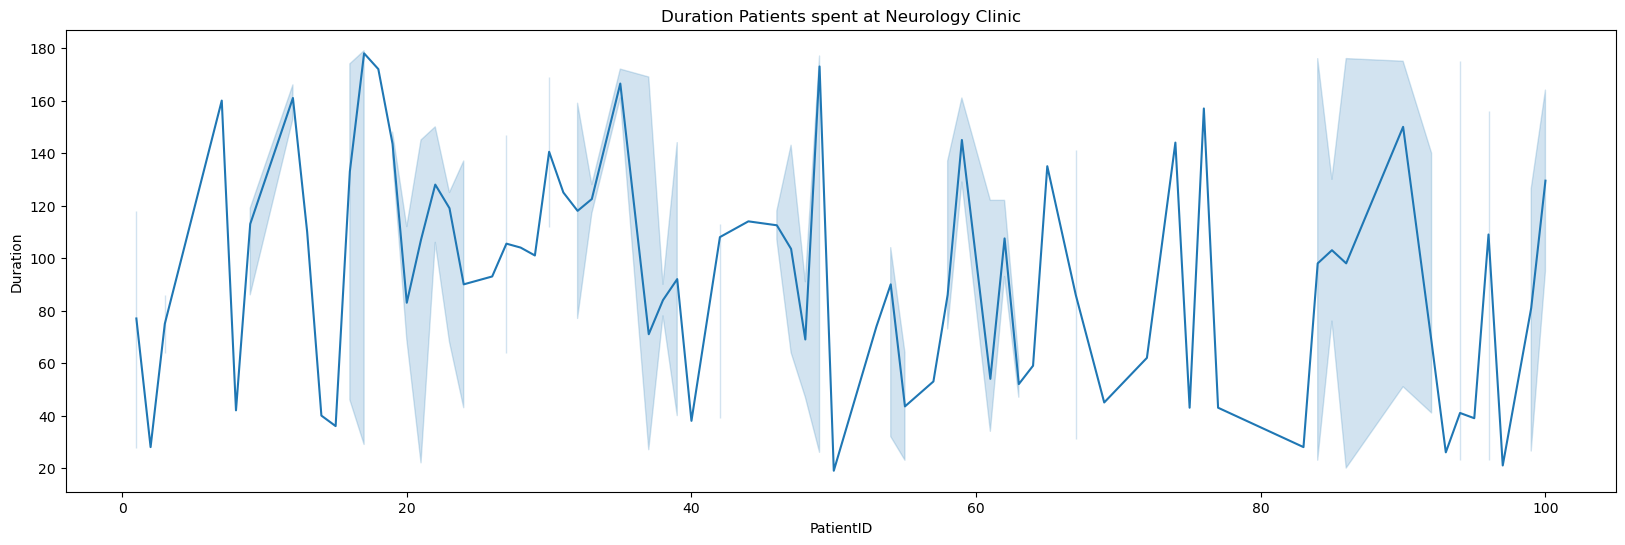

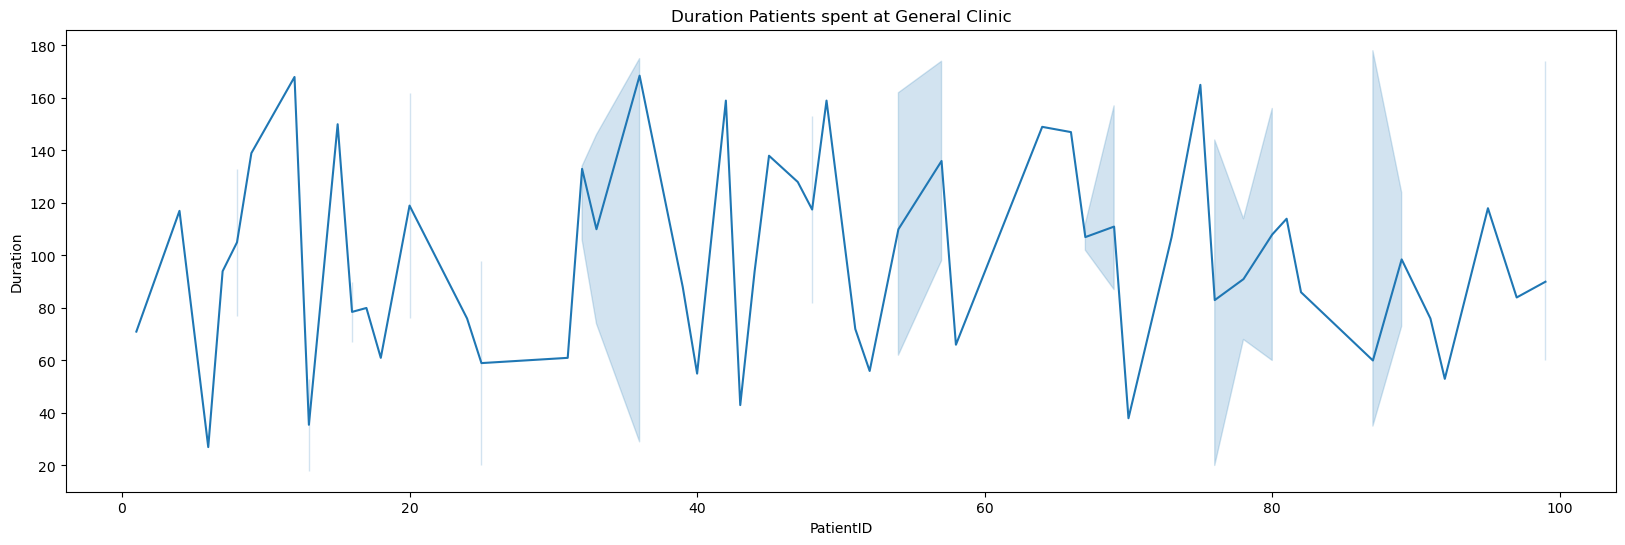

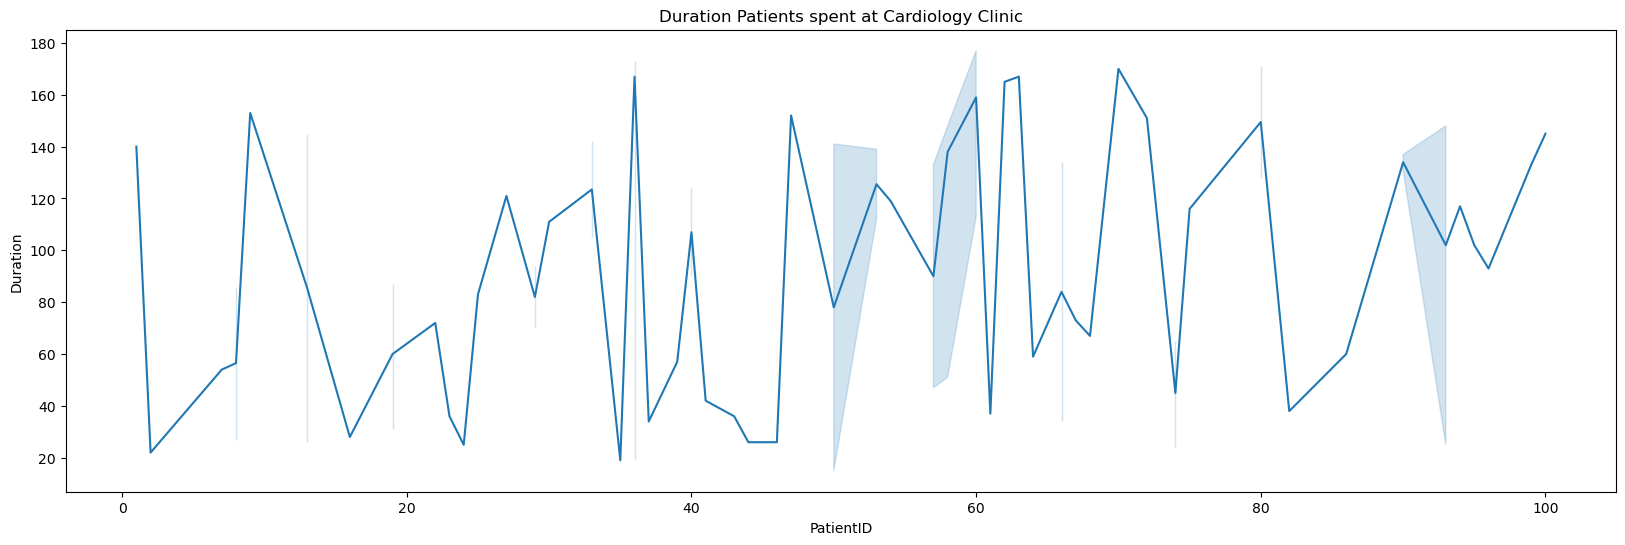

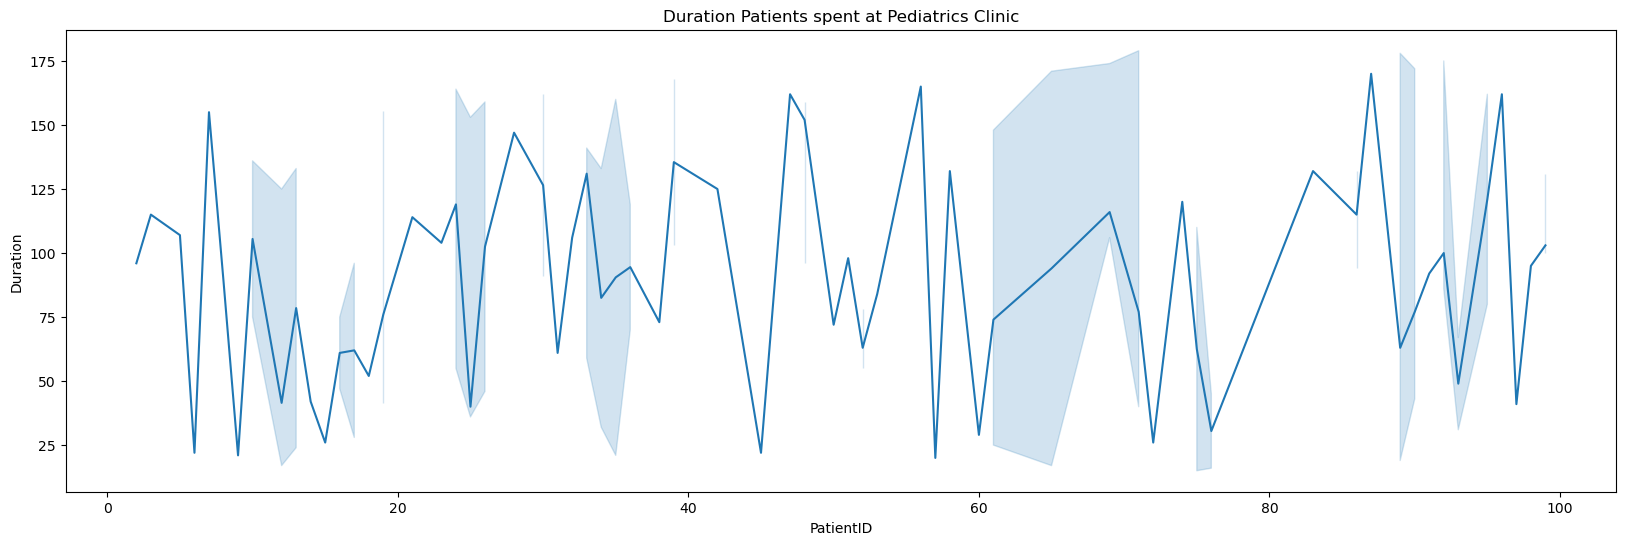

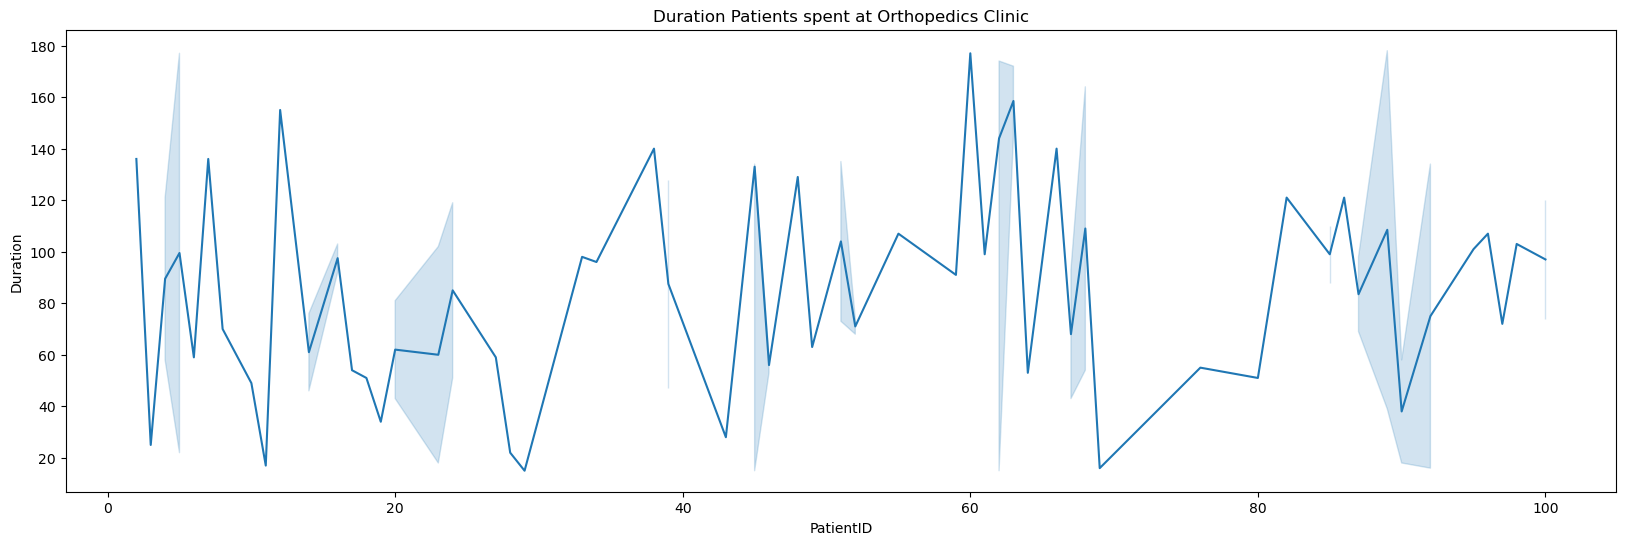

In [11]:
for Specialization in data['Specialization'].unique():
    plt.figure(figsize=(20,6))
    sns.lineplot(x='PatientID', y='Duration', estimator=np.median, data=data[data['Specialization']==Specialization]).set_title('Duration Patients spent at {} Clinic'.format(Specialization))
    plt.show()

In [12]:
data.dtypes

PatientID              int64
PatientName           object
Gender                object
Age                    int64
Location              object
ReasonForVisit        object
Duration               int64
ClinicID               int64
Specialization        object
Age_group             object
LocationCode           int64
GenderCode             int64
VisitCode              int64
SpecializationCode     int64
dtype: object

In [13]:
data['PatientID'] = 'PatientID ' + data['PatientID'].astype(str)

In [14]:
data['ClinicID'] = 'ClinicID ' + data['ClinicID'].astype(str)

In [15]:
data.dtypes

PatientID             object
PatientName           object
Gender                object
Age                    int64
Location              object
ReasonForVisit        object
Duration               int64
ClinicID              object
Specialization        object
Age_group             object
LocationCode           int64
GenderCode             int64
VisitCode              int64
SpecializationCode     int64
dtype: object

In [16]:
data.drop(['LocationCode', 'GenderCode', 'VisitCode', 'SpecializationCode', 'Age_group'], axis=1, inplace=True)

In [17]:
data.dtypes

PatientID         object
PatientName       object
Gender            object
Age                int64
Location          object
ReasonForVisit    object
Duration           int64
ClinicID          object
Specialization    object
dtype: object

In [18]:
pd.get_dummies(data['Duration'])

,15,16,17,18,19,20,21,22,23,24,...,170,171,172,173,174,175,176,177,178,179
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
496,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
497,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
498,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [19]:
df = pd.get_dummies(data)

In [20]:
df.head()

,Age,Duration,PatientID_PatientID 1,PatientID_PatientID 10,PatientID_PatientID 100,PatientID_PatientID 11,PatientID_PatientID 12,PatientID_PatientID 13,PatientID_PatientID 14,PatientID_PatientID 15,...,ClinicID_ClinicID 5,ClinicID_ClinicID 6,ClinicID_ClinicID 7,ClinicID_ClinicID 8,ClinicID_ClinicID 9,Specialization_Cardiology,Specialization_General,Specialization_Neurology,Specialization_Orthopedics,Specialization_Pediatrics
0,56,109,True,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
1,56,71,True,False,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,False
2,56,76,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,56,35,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,56,140,True,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [21]:
df.dtypes

Age                           int64
Duration                      int64
PatientID_PatientID 1          bool
PatientID_PatientID 10         bool
PatientID_PatientID 100        bool
                              ...  
Specialization_Cardiology      bool
Specialization_General         bool
Specialization_Neurology       bool
Specialization_Orthopedics     bool
Specialization_Pediatrics      bool
Length: 233, dtype: object

In [22]:
x = df.drop(['Duration', 'Age'], axis=1)
y = df['Duration']

In [23]:
x.columns

Index(['PatientID_PatientID 1', 'PatientID_PatientID 10',
       'PatientID_PatientID 100', 'PatientID_PatientID 11',
       'PatientID_PatientID 12', 'PatientID_PatientID 13',
       'PatientID_PatientID 14', 'PatientID_PatientID 15',
       'PatientID_PatientID 16', 'PatientID_PatientID 17',
       ...
       'ClinicID_ClinicID 5', 'ClinicID_ClinicID 6', 'ClinicID_ClinicID 7',
       'ClinicID_ClinicID 8', 'ClinicID_ClinicID 9',
       'Specialization_Cardiology', 'Specialization_General',
       'Specialization_Neurology', 'Specialization_Orthopedics',
       'Specialization_Pediatrics'],
      dtype='object', length=231)

In [24]:
y

0      109
1       71
2       76
3       35
4      140
      ... 
495    145
496     74
497    164
498    120
499     95
Name: Duration, Length: 500, dtype: int64

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=1234)

In [26]:
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(350, 231) (150, 231) (350,) (150,)


In [47]:
pipelines = {
    'rf':make_pipeline(RandomForestRegressor(random_state=1234)),
    'gb':make_pipeline(GradientBoostingRegressor(random_state=1234)),
    'ridge':make_pipeline(Ridge(random_state=1234)),
    'lasso':make_pipeline(Lasso(random_state=1234)),
    'enet':make_pipeline(ElasticNet(random_state=1234)),
}

In [49]:
RandomForestRegressor().get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [51]:
hypergrid = {
    'rf' :{
        'randomforestregressor__min_samples_split':[2,4,6],
        'randomforestregressor__min_samples_leaf':[1,2,3]
    },
    'gb' :{
        'gradientboostingregressor__alpha':[0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 0.99]
    },
    'ridge' :{
        'ridge__alpha':[0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 0.99]
    },
    'lasso' :{
        'lasso__alpha':[0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 0.99]
    },
    'enet' :{
        'elasticnet__alpha':[0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 0.99]
    }
}

In [53]:
fit_models = {}
for algo, pipeline in pipelines.items():
    #print(algo)
    #print(pipeline)
    model = GridSearchCV(pipeline, hypergrid[algo], cv=10, n_jobs=-1)
    try:
        print('Starting training for {}.'.format(algo))
        model.fit(x_train, y_train)
        fit_models[algo] = model
        print('{} has been succcesfully fit.'.format(algo))
    except NotFittedError as e:
        Print(repr(e))

Starting training for rf.
rf has been succcesfully fit.
Starting training for gb.
gb has been succcesfully fit.
Starting training for ridge.
ridge has been succcesfully fit.
Starting training for lasso.
lasso has been succcesfully fit.
Starting training for enet.
enet has been succcesfully fit.


In [57]:
fit_models['rf'].predict(x_test)

array([ 98.27964732,  91.58268759,  91.88840568,  98.73809626,
        98.18664791, 102.09510162, 106.30602549,  97.63265801,
        93.00468235,  74.74643279,  81.87911652,  79.74478175,
       125.50935961,  83.78785317,  89.5034228 ,  66.97461222,
        98.80088054,  72.45382468,  91.84221356, 100.62419481,
        85.36744408,  89.80749753, 107.89840571,  74.08752187,
       104.58273224, 105.83323046, 111.1644569 , 115.27751332,
        76.19458966,  94.70315801, 135.46634524,  97.8800204 ,
       112.52008711,  78.78965906,  88.21502975,  95.77293359,
        90.60240115, 114.35222253,  95.09835698, 103.55386111,
        64.79002844,  84.52413362,  61.43370058,  87.4533925 ,
       112.11501046, 103.91798157,  91.36056674,  78.65196225,
        88.70019733, 100.89387912,  66.67506566,  86.90124634,
        77.23876432,  93.87613836,  85.3775525 ,  51.57157057,
        99.99800361, 112.34512829,  93.15964351, 104.85916198,
        74.69117888,  88.70019733,  89.70314791,  83.94

In [65]:
for algo,model in fit_models.items():
    yhat = model.predict(x_test)
    print('{} scores - R2:{} MAE:{}'.format(algo, r2_score(y_test, yhat), mean_absolute_error(y_test, yhat)))

rf scores - R2:-0.15450772109119626 MAE:46.292252367186194
gb scores - R2:-0.15173972198686325 MAE:45.95825248816388
ridge scores - R2:-0.3634365772581123 MAE:49.25077087198555
lasso scores - R2:-0.019851415280166096 MAE:44.244360397954914
enet scores - R2:-0.014433372592090654 MAE:44.095716267460354
